<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/Parsons_Political_System_Experiment_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Вычислительная модель политической системы Толкотта Парсонса

**Стадия 2: воспроизводимый вычислительный эксперимент**  
Страны: США, Германия, Китай, Индия, Бразилия, Южная Африка, Япония, Турция, Россия, Казахстан.  
Период: 2000–2025, годовые наблюдения.  
Режим: 10 сидов, 24 класса `strain`, 15 системных реакций, непараметрические тесты.

> **Теоретическое ограничение.** Онтологические сущности и названия процессов берутся из работ Толкотта Парсонса. Формулы, индексы, алгоритмы и статистические тесты являются вычислительной экспликацией, а не формулами самого Парсонса.

Основное состояние общества:

\[
\mathbf S^{soc}_{c,t}=[A^{soc}_{c,t},G^{soc}_{c,t},I^{soc}_{c,t},L^{soc}_{c,t}]^\top.
\]

Основное состояние политической подсистемы:

\[
\mathbf S^{pol}_{c,t}=[A^{pol}_{c,t},G^{pol}_{c,t},I^{pol}_{c,t},L^{pol}_{c,t}]^\top.
\]

Системный индекс функционального равновесия:

\[
FE_{c,t}=(A_{c,t}G_{c,t}I_{c,t}L_{c,t})^{1/4},\qquad
Bottleneck_{c,t}=\min(A,G,I,L).
\]

## 0. Среда выполнения

Ноутбук рассчитан на Google Colab CPU/T4/L4 и корректно отображается на GitHub. Все интерактивные элементы имеют статические аналоги. Один сквозной индикатор показывает прогресс всего эксперимента.

In [1]:
#@title 0.1. Установка зависимостей (Google Colab / локальная среда)
import sys, subprocess, importlib.util

REQUIRED = {
    "openpyxl": "openpyxl>=3.1",
    "xlsxwriter": "xlsxwriter>=3.2",
    "statsmodels": "statsmodels>=0.14",
    "tqdm": "tqdm>=4.66",
    "requests": "requests>=2.31",
    "scipy": "scipy>=1.11",
    "sklearn": "scikit-learn>=1.3",
}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Dependencies ready.")

Dependencies ready.


In [2]:
#@title 0.2. Импорты, конфигурация, воспроизводимость
from __future__ import annotations

import os, json, math, time, random, hashlib, warnings, zipfile
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from tqdm.auto import tqdm
from scipy import stats
from scipy.special import expit
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

@dataclass(frozen=True)
class Config:
    countries: Tuple[str, ...] = ("USA","DEU","CHN","IND","BRA","ZAF","JPN","TUR","RUS","KAZ")
    years: Tuple[int, ...] = tuple(range(2000, 2026))
    train_end: int = 2018
    validation_end: int = 2022
    n_seeds: int = 10
    horizon: int = 10
    equilibrium_window: int = 3
    breakdown_window: int = 2
    output_dir: str = "/content/parsons_experiment_outputs" if Path("/content").exists() else "./parsons_experiment_outputs"
    cache_dir: str = "/content/parsons_cache" if Path("/content").exists() else "./parsons_cache"
    data_mode: str = "auto"  # auto | worldbank | demo
    random_seed: int = 20260803
    ridge_alpha: float = 2.0
    shock_scale: float = 0.22
    noise_scale: float = 0.012
    threshold_quantile_low: float = 0.15
    threshold_quantile_high: float = 0.85

CFG = Config()
OUT = Path(CFG.output_dir); OUT.mkdir(parents=True, exist_ok=True)
CACHE = Path(CFG.cache_dir); CACHE.mkdir(parents=True, exist_ok=True)
for sub in ["figures_png","figures_svg","tables_csv","logs"]:
    (OUT/sub).mkdir(exist_ok=True)

random.seed(CFG.random_seed)
np.random.seed(CFG.random_seed)

print(asdict(CFG))

{'countries': ('USA', 'DEU', 'CHN', 'IND', 'BRA', 'ZAF', 'JPN', 'TUR', 'RUS', 'KAZ'), 'years': (2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025), 'train_end': 2018, 'validation_end': 2022, 'n_seeds': 10, 'horizon': 10, 'equilibrium_window': 3, 'breakdown_window': 2, 'output_dir': '/content/parsons_experiment_outputs', 'cache_dir': '/content/parsons_cache', 'data_mode': 'auto', 'random_seed': 20260803, 'ridge_alpha': 2.0, 'shock_scale': 0.22, 'noise_scale': 0.012, 'threshold_quantile_low': 0.15, 'threshold_quantile_high': 0.85}


## 1. Онтологический паспорт эксперимента

### 1.1. Уровни

1. `society` — общество как социальная система;
2. `polity` — политическая подсистема, специализирующаяся на коллективном целедостижении;
3. `organization` — коллективы со специфическими целями, границами, ролями и authority.

### 1.2. Генерализованные символические средства

\[
\mathbf M_{c,t}=[money,power,influence,value\text{-}commitments]^\top.
\]

### 1.3. Напряжение

\[
Strain_{pq,t}=\frac{|J^{p\to q}_t-\widehat J^{p\to q}_t|+|J^{q\to p}_t-\widehat J^{q\to p}_t|}{2}.
\]

В вычислениях `strain` оценивается как отклонение текущих функциональных и межподсистемных отношений от институционализированного исторического ожидания.

In [3]:
#@title 1.4. Онтология в коде: AGIL, strain и системные реакции
AGIL = ("A", "G", "I", "L")
LEVELS = ("society", "polity", "organization")
MEDIA = ("money", "power", "influence", "value_commitments")

STRAIN_CLASSES = (
    "adaptive_insufficiency", "adaptive_allocation_strain",
    "goal_definition_strain", "goal_priority_strain", "goal_attainment_strain", "mobilization_strain",
    "integrative_coordination_strain", "membership_strain", "solidarity_strain",
    "pattern_maintenance_strain", "motivational_strain", "socialization_strain",
    "normative_expectation_strain", "legitimation_strain", "role_strain", "role_conflict_strain",
    "authority_strain", "sanction_strain", "money_medium_strain", "power_medium_strain",
    "influence_medium_strain", "value_commitment_strain", "interchange_strain", "boundary_strain",
)

REACTIONS = (
    "resolution", "arrestation", "isolation", "structural_change", "differentiation",
    "adaptive_upgrading", "inclusion", "value_generalization", "institutionalization",
    "legitimation", "socialization", "social_control", "allocation", "mobilization",
    "re_specification_of_goals",
)

assert len(STRAIN_CLASSES) == 24
assert len(REACTIONS) == 15

ONTOLOGY_HASH = hashlib.sha256(
    ("|".join(AGIL+STRAIN_CLASSES+REACTIONS)).encode("utf-8")
).hexdigest()
print("Ontology hash:", ONTOLOGY_HASH)

Ontology hash: 2587d9a172a071f7d9c208339e832a6c94a9eb9251aede45db69614b3f897019


## 2. Сквозной прогресс-бар

Прогресс считается по крупным этапам: данные, аудит, индексы, переходная модель, сценарии, 10 сидов, статистика, визуализации и экспорт. Вложенные циклы не создают конкурирующих индикаторов.

In [4]:
#@title 2.1. Единый диспетчер прогресса
class GlobalProgress:
    def __init__(self, total: int):
        self.bar = tqdm(total=total, desc="BRICS–Parsons experiment", unit="step", dynamic_ncols=True)
    def step(self, label: str, n: int = 1):
        self.bar.set_postfix_str(label[:90])
        self.bar.update(n)
    def close(self):
        self.bar.close()

TOTAL_STEPS = 8 + CFG.n_seeds * len(REACTIONS) + 7
PROGRESS = GlobalProgress(TOTAL_STEPS)

BRICS–Parsons experiment:   0%|          | 0/165 [00:00<?, ?step/s]

## 3. Эмпирический слой

Индикаторы — наблюдаемые прокси, а не тождественные измерения AGIL. Базовый загрузчик использует World Bank API. Пользовательский файл `parsons_panel.csv` или `parsons_panel.xlsx` в `/content` имеет приоритет.

Минимальная схема пользовательской панели:

`country, year, indicator_code, value, status, source`

In [5]:
#@title 3.1. Карта международных индикаторов
# Техническая карта прокси. Теоретический смысл задаётся AGIL-блоком, а не названием показателя.
INDICATORS = {
    # Adaptation / economy
    "NY.GDP.PCAP.PP.KD": ("A", "gdp_per_capita_ppp", +1),
    "NY.GDP.MKTP.KD.ZG": ("A", "gdp_growth", +1),
    "NE.GDI.TOTL.ZS": ("A", "gross_capital_formation", +1),
    "SL.EMP.TOTL.SP.ZS": ("A", "employment_ratio", +1),
    "SL.UEM.TOTL.ZS": ("A", "unemployment", -1),
    "NE.TRD.GNFS.ZS": ("A", "trade_openness", +1),
    "EG.ELC.ACCS.ZS": ("A", "electricity_access", +1),
    "GC.DOD.TOTL.GD.ZS": ("A", "central_government_debt", -1),
    # Goal-attainment / polity
    "GE.EST": ("G", "government_effectiveness", +1),
    "GC.TAX.TOTL.GD.ZS": ("G", "tax_revenue", +1),
    "NE.CON.GOVT.ZS": ("G", "government_consumption", +1),
    "GB.XPD.RSDV.GD.ZS": ("G", "research_expenditure", +1),
    "SP.POP.TOTL": ("G", "population_scale", +1),
    "CC.EST": ("G", "control_of_corruption", +1),
    # Integration / societal community
    "RL.EST": ("I", "rule_of_law", +1),
    "PV.EST": ("I", "political_stability_absence_violence", +1),
    "SI.POV.GINI": ("I", "gini", -1),
    "VC.IHR.PSRC.P5": ("I", "intentional_homicides", -1),
    "SE.ENR.SECO.FM.ZS": ("I", "gender_parity_secondary", +1),
    "SH.XPD.GHED.GD.ZS": ("I", "domestic_public_health_expenditure", +1),
    # Pattern-maintenance / fiduciary system
    "SE.SEC.ENRR": ("L", "secondary_enrollment", +1),
    "SE.TER.ENRR": ("L", "tertiary_enrollment", +1),
    "SE.XPD.TOTL.GD.ZS": ("L", "education_expenditure", +1),
    "SE.PRM.CMPT.ZS": ("L", "primary_completion", +1),
    "SP.DYN.LE00.IN": ("L", "life_expectancy", +1),
    "IT.NET.USER.ZS": ("L", "internet_use", +1),
}
assert len(INDICATORS) >= 20

In [6]:
#@title 3.2. Загрузка пользовательской панели или World Bank API
WB_BASE = "https://api.worldbank.org/v2"

def _load_user_panel() -> Optional[pd.DataFrame]:
    candidates = [Path("/content/parsons_panel.csv"), Path("/content/parsons_panel.xlsx"),
                  Path("./parsons_panel.csv"), Path("./parsons_panel.xlsx")]
    for p in candidates:
        if p.exists():
            df = pd.read_csv(p) if p.suffix == ".csv" else pd.read_excel(p)
            required = {"country","year","indicator_code","value"}
            if not required.issubset(df.columns):
                raise ValueError(f"{p} must include {sorted(required)}")
            df["status"] = df.get("status", "observed")
            df["source"] = df.get("source", str(p))
            return df
    return None

def wb_fetch_indicator(indicator: str) -> pd.DataFrame:
    cache = CACHE / f"wb_{indicator.replace('.','_')}.csv"
    if cache.exists():
        return pd.read_csv(cache)
    countries = ";".join(CFG.countries)
    url = f"{WB_BASE}/country/{countries}/indicator/{indicator}"
    params = {"format":"json", "per_page":20000, "date":f"{min(CFG.years)}:{max(CFG.years)}"}
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    payload = r.json()
    rows = []
    if isinstance(payload, list) and len(payload) > 1 and payload[1]:
        for x in payload[1]:
            rows.append({
                "country": x.get("countryiso3code"),
                "year": int(x["date"]),
                "indicator_code": indicator,
                "value": x.get("value"),
                "status": "observed",
                "source": "World Bank API",
            })
    out = pd.DataFrame(rows)
    out.to_csv(cache, index=False)
    return out

def make_demo_panel() -> pd.DataFrame:
    rng = np.random.default_rng(CFG.random_seed)
    rows=[]
    for ci,c in enumerate(CFG.countries):
        country_shift = rng.normal(0,0.35)
        for code,(f,name,direction) in INDICATORS.items():
            base = rng.normal(0,1)+country_shift
            trend = rng.normal(0.015,0.008)
            for y in CFG.years:
                val = base + trend*(y-min(CFG.years)) + rng.normal(0,0.12)
                if rng.random() < 0.07 or (y==2025 and rng.random()<0.45): val=np.nan
                rows.append({"country":c,"year":y,"indicator_code":code,"value":val,
                             "status":"synthetic_demo","source":"synthetic_demo"})
    return pd.DataFrame(rows)

user_panel = _load_user_panel()
if user_panel is not None:
    raw = user_panel.copy(); DATA_MODE_USED="user_panel"
elif CFG.data_mode in ("auto","worldbank"):
    fetched=[]; failures=[]
    for ind in INDICATORS:
        try: fetched.append(wb_fetch_indicator(ind))
        except Exception as e: failures.append((ind,str(e)))
    raw = pd.concat(fetched, ignore_index=True) if fetched else pd.DataFrame()
    if raw.empty or raw["value"].notna().mean() < 0.20:
        if CFG.data_mode == "worldbank": raise RuntimeError(f"World Bank download failed: {failures[:3]}")
        raw=make_demo_panel(); DATA_MODE_USED="synthetic_demo"
    else:
        DATA_MODE_USED="worldbank"
else:
    raw=make_demo_panel(); DATA_MODE_USED="synthetic_demo"

raw = raw[raw.country.isin(CFG.countries) & raw.year.isin(CFG.years)].copy()
raw["value"] = pd.to_numeric(raw["value"], errors="coerce")
PROGRESS.step(f"data loaded: {DATA_MODE_USED}")
print(DATA_MODE_USED, raw.shape, "non-null", raw.value.notna().mean())

synthetic_demo (6760, 6) non-null 0.9087278106508876


In [7]:
#@title 3.3. Аудит покрытия и статуса 2025 года
coverage = (raw.assign(observed=raw.value.notna())
            .groupby(["indicator_code","country"], as_index=False)
            .agg(first_year=("year", lambda s: int(s.min())),
                 last_year=("year", lambda s: int(s.max())),
                 n_rows=("year","size"), observed=("observed","sum")))
coverage["coverage_rate"] = coverage["observed"] / len(CFG.years)
coverage_2025 = (raw[raw.year==2025]
                 .groupby("indicator_code",as_index=False)
                 .agg(countries_present=("value",lambda s:int(s.notna().sum())),
                      statuses=("status",lambda s:", ".join(sorted(set(map(str,s)))))))

quality = {
    "data_mode": DATA_MODE_USED,
    "rows": len(raw),
    "non_null_rate": float(raw.value.notna().mean()),
    "countries": int(raw.country.nunique()),
    "indicators": int(raw.indicator_code.nunique()),
    "years": [int(raw.year.min()), int(raw.year.max())],
}
(OUT/"logs"/"data_quality.json").write_text(json.dumps(quality,ensure_ascii=False,indent=2),encoding="utf-8")
PROGRESS.step("coverage audited")
display(coverage.sort_values("coverage_rate").head(20))

,indicator_code,country,first_year,last_year,n_rows,observed,coverage_rate
167,SE.SEC.ENRR,TUR,2000,2025,26,19,0.730769
117,NY.GDP.PCAP.PP.KD,TUR,2000,2025,26,19,0.730769
54,GE.EST,JPN,2000,2025,26,20,0.769231
77,NE.CON.GOVT.ZS,TUR,2000,2025,26,20,0.769231
149,SE.ENR.SECO.FM.ZS,ZAF,2000,2025,26,20,0.769231
4,CC.EST,JPN,2000,2025,26,20,0.769231
109,NY.GDP.MKTP.KD.ZG,ZAF,2000,2025,26,20,0.769231
55,GE.EST,KAZ,2000,2025,26,20,0.769231
186,SE.XPD.TOTL.GD.ZS,RUS,2000,2025,26,21,0.807692
161,SE.SEC.ENRR,CHN,2000,2025,26,21,0.807692


## 4. Train-only preprocessing и построение AGIL

Для показателя \(x_i\) применяется робастная нормализация по обучающему периоду:

\[
z_{i,c,t}=\frac{x_{i,c,t}-Median_{train}(x_i)}{IQR_{train}(x_i)+\epsilon}.
\]

После преобразования в \([0,1]\) направление отрицательных индикаторов разворачивается. Пропуски заполняются только внутри страны: интерполяцией между наблюдаемыми годами, затем обучающей медианой индикатора. Флаг импутации сохраняется.

In [8]:
#@title 4.1. Робастное преобразование и импутация с флагами
indicator_meta = pd.DataFrame([
    {"indicator_code":k,"function":v[0],"indicator_name":v[1],"direction":v[2]}
    for k,v in INDICATORS.items()
])
raw2 = raw.merge(indicator_meta, on="indicator_code", how="inner")
raw2["was_missing"] = raw2.value.isna()

# Полная сетка
idx = pd.MultiIndex.from_product([CFG.countries, CFG.years, list(INDICATORS)],
                                 names=["country","year","indicator_code"])
panel = (raw2.set_index(["country","year","indicator_code"])
         .reindex(idx).reset_index()
         .merge(indicator_meta,on="indicator_code",how="left",suffixes=("","_meta")))
panel["was_missing"] = panel["value"].isna()
panel["status"] = panel["status"].fillna("missing")
panel["source"] = panel["source"].fillna("none")

# Интерполяция только по времени внутри страны-индикатора
panel["value_interp"] = (panel.sort_values("year")
    .groupby(["country","indicator_code"])["value"]
    .transform(lambda s: s.interpolate(limit_area="inside")))

train = panel.year <= CFG.train_end
train_stats = (panel[train].groupby("indicator_code")["value_interp"]
               .agg(median="median", q1=lambda s:s.quantile(.25), q3=lambda s:s.quantile(.75))
               .reset_index())
train_stats["iqr"] = (train_stats.q3-train_stats.q1).replace(0,np.nan).fillna(1.0)
panel = panel.merge(train_stats[["indicator_code","median","iqr"]],on="indicator_code",how="left")
panel["value_filled"] = panel.value_interp.fillna(panel["median"])
panel["imputed"] = panel.value.isna()
panel["z"] = (panel.value_filled-panel["median"])/(panel["iqr"]+1e-9)
panel["scaled"] = expit(panel["z"])
panel.loc[panel.direction<0,"scaled"] = 1-panel.loc[panel.direction<0,"scaled"]
panel["scaled"] = panel.scaled.clip(1e-4,1-1e-4)

PROGRESS.step("train-only preprocessing")
print("Imputation rate:", panel.imputed.mean())

Imputation rate: 0.09127218934911242


In [9]:
#@title 4.2. Индексы AGIL, functional equilibrium и bottleneck
# Равные веса — основной прозрачный вариант.
agil = (panel.groupby(["country","year","function"],as_index=False)
        .agg(score=("scaled","mean"),
             n_indicators=("scaled","size"),
             imputation_rate=("imputed","mean")))
wide = agil.pivot(index=["country","year"],columns="function",values="score").reset_index()
for f in AGIL:
    if f not in wide: wide[f]=np.nan
wide["FE"] = np.prod(wide[list(AGIL)].clip(1e-6,1),axis=1)**(1/4)
wide["Bottleneck"] = wide[list(AGIL)].min(axis=1)
wide["Imbalance"] = wide[list(AGIL)].std(axis=1,ddof=0)
wide["NormGap"] = 1 - (wide["I"]*wide["L"])**0.5

# Межфункциональное strain как отклонение парных разностей от train expectation.
pairs=[]
for i,p in enumerate(AGIL):
    for q in AGIL[i+1:]:
        pairs.append((p,q))
train_w = wide[wide.year<=CFG.train_end]
for p,q in pairs:
    expected = float((train_w[p]-train_w[q]).median())
    wide[f"strain_{p}{q}"] = ((wide[p]-wide[q])-expected).abs()
strain_cols=[f"strain_{p}{q}" for p,q in pairs]
wide["Strain"] = wide[strain_cols].mean(axis=1)
wide["Disequilibrium"] = .45*wide.Strain + .35*wide.Imbalance + .20*wide.NormGap

PROGRESS.step("AGIL indices built")
display(wide.head())

function,country,year,A,G,I,L,FE,Bottleneck,Imbalance,NormGap,strain_AG,strain_AI,strain_AL,strain_GI,strain_GL,strain_IL,Strain,Disequilibrium
0,BRA,2000,0.476414,0.458527,0.539522,0.363530,0.454961,0.363530,0.063049,0.557132,0.003062,0.040481,0.139108,0.066730,0.102459,0.161606,0.085574,0.172002
1,BRA,2001,0.448824,0.404836,0.541803,0.351559,0.431319,0.351559,0.069746,0.563565,0.029162,0.070353,0.123488,0.122702,0.060739,0.175858,0.097050,0.180797
2,BRA,2002,0.438357,0.413068,0.557836,0.358917,0.436353,0.358917,0.072752,0.552544,0.010463,0.096853,0.105663,0.130503,0.061613,0.184533,0.098272,0.180194
3,BRA,2003,0.456577,0.402284,0.565767,0.365303,0.441402,0.365303,0.075614,0.545383,0.039467,0.086563,0.117496,0.149218,0.044442,0.186077,0.103877,0.182286
4,BRA,2004,0.458443,0.419652,0.540968,0.371631,0.443470,0.371631,0.062023,0.551625,0.023966,0.059898,0.113035,0.107051,0.055482,0.154950,0.085730,0.170612


## 5. Калибровка переходной модели

Техническая функция перехода:

\[
\mathbf X_{c,t+1}=\sigma\left(
\mathbf B_c\mathbf X_{c,t}
+\mathbf H_c\mathbf q_k
+\mathbf U_c\mathbf a_r
-\mathbf K_c\,Strain_{c,t}
+\varepsilon_{c,t}
\right).
\]

На исторических данных оценивается только базовая динамика \(\mathbf B_c\). Воздействия `strain` и реакции задаются прозрачными матрицами, выведенными из онтологии, и проверяются анализом чувствительности.

In [10]:
#@title 5.1. Оценка базовой динамики Ridge и историческая валидация
FEATURES = list(AGIL)+["Strain","Disequilibrium","FE","Bottleneck"]
TARGETS = list(AGIL)
rows=[]
for c,g in wide.sort_values("year").groupby("country"):
    g=g.copy()
    for f in TARGETS: g[f"next_{f}"]=g[f].shift(-1)
    g["next_year"]=g.year.shift(-1)
    rows.append(g)
trans = pd.concat(rows,ignore_index=True).dropna(subset=[f"next_{f}" for f in TARGETS])

models={}; validation=[]
for c in CFG.countries:
    gc=trans[trans.country==c]
    tr=gc[gc.year<=CFG.train_end]
    va=gc[(gc.year>CFG.train_end)&(gc.year<=CFG.validation_end)]
    models[c]={}
    for f in TARGETS:
        m=Ridge(alpha=CFG.ridge_alpha)
        m.fit(tr[FEATURES],tr[f"next_{f}"])
        models[c][f]=m
        if len(va):
            pred=np.clip(m.predict(va[FEATURES]),1e-4,1-1e-4)
            validation.append({"country":c,"target":f,"mse":mean_squared_error(va[f"next_{f}"],pred)})
validation_df=pd.DataFrame(validation)
PROGRESS.step("transition models calibrated")
display(validation_df.groupby("target").mse.agg(["mean","median","max"]))

,mean,median,max
target,,,
A,0.000441,0.000347,0.001637
G,0.000610,0.000529,0.001107
I,0.000379,0.000452,0.000630
L,0.000778,0.000609,0.001861


In [11]:
#@title 5.2. Пороговые значения breakdown и нового равновесия
train_w = wide[wide.year<=CFG.train_end]
THRESH = {
    "bottleneck": float(train_w.Bottleneck.quantile(CFG.threshold_quantile_low)),
    "strain": float(train_w.Strain.quantile(CFG.threshold_quantile_high)),
    "diseq": float(train_w.Disequilibrium.quantile(CFG.threshold_quantile_high)),
    "institutionalization": float(((train_w.I*train_w.L)**0.5).quantile(CFG.threshold_quantile_low)),
    "delta": float(train_w.groupby("country")[list(AGIL)].diff().pow(2).sum(axis=1).pow(.5).quantile(.75)),
}
print(THRESH)

{'bottleneck': 0.3784439639364087, 'strain': 0.0816162884598543, 'diseq': 0.1559790374346794, 'institutionalization': 0.4485807700402998, 'delta': 0.025515480393705124}


## 6. Сценарии `strain`

Каждый сценарий является профилем одного из 24 парсонсовских классов напряжения. Сценарий воздействует на AGIL, `strain`, институционализацию и межфункциональные связи. Современное событие может быть позднее закодировано как комбинация профилей, но не становится новым теоретическим классом.

In [12]:
#@title 6.1. Матрица воздействия 24 классов strain
# Столбцы A,G,I,L. Отрицательные значения означают функциональное давление.
def v(a=0,g=0,i=0,l=0): return np.array([a,g,i,l],dtype=float)
STRAIN_IMPACT = {
 "adaptive_insufficiency":v(a=-1.0,g=-.20,i=-.10,l=-.05),
 "adaptive_allocation_strain":v(a=-.85,g=-.25,i=-.25,l=-.05),
 "goal_definition_strain":v(g=-1.0,i=-.20,l=-.20),
 "goal_priority_strain":v(g=-.85,i=-.35,l=-.10),
 "goal_attainment_strain":v(a=-.10,g=-1.0,i=-.20,l=-.10),
 "mobilization_strain":v(a=-.25,g=-.90,i=-.10,l=-.05),
 "integrative_coordination_strain":v(g=-.15,i=-1.0,l=-.15),
 "membership_strain":v(i=-.90,l=-.25),
 "solidarity_strain":v(g=-.10,i=-1.0,l=-.30),
 "pattern_maintenance_strain":v(i=-.15,l=-1.0),
 "motivational_strain":v(g=-.25,i=-.10,l=-.90),
 "socialization_strain":v(i=-.20,l=-1.0),
 "normative_expectation_strain":v(g=-.10,i=-.85,l=-.55),
 "legitimation_strain":v(g=-.45,i=-.45,l=-1.0),
 "role_strain":v(g=-.15,i=-.75,l=-.30),
 "role_conflict_strain":v(g=-.25,i=-.90,l=-.30),
 "authority_strain":v(g=-.90,i=-.50,l=-.30),
 "sanction_strain":v(g=-.15,i=-.80,l=-.35),
 "money_medium_strain":v(a=-1.0,g=-.25),
 "power_medium_strain":v(g=-1.0,i=-.35,l=-.25),
 "influence_medium_strain":v(g=-.10,i=-1.0,l=-.20),
 "value_commitment_strain":v(i=-.25,l=-1.0),
 "interchange_strain":v(a=-.45,g=-.45,i=-.45,l=-.45),
 "boundary_strain":v(a=-.15,g=-.25,i=-.85,l=-.25),
}
assert set(STRAIN_IMPACT)==set(STRAIN_CLASSES)
scenario_catalog=pd.DataFrame([
    {"scenario_id":f"S{i+1:02d}","strain_class":s,"intensity":CFG.shock_scale,
     **{f"impact_{f}":STRAIN_IMPACT[s][j] for j,f in enumerate(AGIL)}}
    for i,s in enumerate(STRAIN_CLASSES)
])
PROGRESS.step("strain scenarios constructed")

## 7. Системные реакции

В модели используются только процессы онтологии: `resolution`, `arrestation`, `isolation`, `structural change`, `differentiation`, `adaptive upgrading`, `inclusion`, `value generalization`, `institutionalization`, `legitimation`, `socialization`, `social control`, `allocation`, `mobilization`, `re-specification of goals`.

In [13]:
#@title 7.1. Прозрачные профили реакций
# direct: немедленный функциональный вклад; strain_reduction: снижение распространения strain;
# structural: скорость изменения базовой структуры; inst: вклад в институционализацию.
REACTION_PROFILE = {
 "resolution":                 dict(direct=v(.10,.12,.16,.14), strain_reduction=.55, structural=.00, inst=.12),
 "arrestation":                dict(direct=v(.04,.05,.07,.04), strain_reduction=.35, structural=.00, inst=.02),
 "isolation":                  dict(direct=v(.02,.03,.08,.02), strain_reduction=.50, structural=.00, inst=.00),
 "structural_change":          dict(direct=v(.04,.06,.08,.07), strain_reduction=.25, structural=.18, inst=.06),
 "differentiation":            dict(direct=v(.08,.08,.07,.05), strain_reduction=.15, structural=.14, inst=.03),
 "adaptive_upgrading":         dict(direct=v(.18,.07,.03,.03), strain_reduction=.12, structural=.08, inst=.02),
 "inclusion":                  dict(direct=v(.02,.03,.18,.08), strain_reduction=.22, structural=.05, inst=.08),
 "value_generalization":       dict(direct=v(.01,.04,.08,.18), strain_reduction=.20, structural=.07, inst=.12),
 "institutionalization":       dict(direct=v(.02,.05,.11,.13), strain_reduction=.25, structural=.04, inst=.18),
 "legitimation":               dict(direct=v(.01,.10,.09,.16), strain_reduction=.20, structural=.00, inst=.15),
 "socialization":              dict(direct=v(.01,.02,.07,.17), strain_reduction=.12, structural=.00, inst=.10),
 "social_control":             dict(direct=v(.01,.04,.13,.05), strain_reduction=.22, structural=.00, inst=.05),
 "allocation":                 dict(direct=v(.15,.08,.04,.02), strain_reduction=.10, structural=.03, inst=.01),
 "mobilization":               dict(direct=v(.07,.18,.03,.02), strain_reduction=.08, structural=.00, inst=.00),
 "re_specification_of_goals":  dict(direct=v(.02,.16,.07,.08), strain_reduction=.18, structural=.04, inst=.07),
}
assert set(REACTION_PROFILE)==set(REACTIONS)
reaction_catalog=pd.DataFrame([
    {"reaction":r, **{f"direct_{f}":p["direct"][j] for j,f in enumerate(AGIL)},
     "strain_reduction":p["strain_reduction"],"structural":p["structural"],"institutionalization":p["inst"]}
    for r,p in REACTION_PROFILE.items()
])

In [14]:
#@title 7.2. Симулятор многоуровневого перехода
BASE_YEAR = int(min(max(CFG.validation_end, min(CFG.years)), max(CFG.years)))
base_states = wide[wide.year==BASE_YEAR].set_index("country")
if len(base_states)<len(CFG.countries):
    # Последнее доступное состояние каждой страны
    base_states = wide.sort_values("year").groupby("country").tail(1).set_index("country")

def derive_metrics(x: np.ndarray, expected_pair_diff: Dict[str,float]) -> Dict[str,float]:
    x=np.clip(x,1e-4,1-1e-4)
    pairvals=[]
    for p,q in pairs:
        pairvals.append(abs((x[AGIL.index(p)]-x[AGIL.index(q)])-expected_pair_diff[f"{p}{q}"]))
    strain=float(np.mean(pairvals))
    fe=float(np.prod(x)**.25); bott=float(x.min()); imb=float(x.std())
    normgap=float(1-math.sqrt(x[2]*x[3]))
    diseq=.45*strain+.35*imb+.20*normgap
    inst=float(math.sqrt(x[2]*x[3]))
    return dict(FE=fe,Bottleneck=bott,Imbalance=imb,NormGap=normgap,Strain=strain,Disequilibrium=diseq,Institutionalization=inst)

expected_pair_diff={}
for p,q in pairs:
    expected_pair_diff[f"{p}{q}"]=float((train_w[p]-train_w[q]).median())

def historical_next(country: str, x: np.ndarray, metrics: Dict[str,float]) -> np.ndarray:
    row=np.array([*x,metrics["Strain"],metrics["Disequilibrium"],metrics["FE"],metrics["Bottleneck"]]).reshape(1,-1)
    return np.array([models[country][f].predict(row)[0] for f in AGIL])

def simulate_one(country: str, scenario: str, reaction: str, seed: int) -> pd.DataFrame:
    rng=np.random.default_rng(seed + 1009*CFG.countries.index(country) + 9176*STRAIN_CLASSES.index(scenario))
    x=base_states.loc[country,list(AGIL)].to_numpy(float)
    impact=STRAIN_IMPACT[scenario]*CFG.shock_scale
    rp=REACTION_PROFILE[reaction]
    rows=[]; structural_memory=np.zeros(4)
    for h in range(CFG.horizon+1):
        met=derive_metrics(x,expected_pair_diff)
        rows.append({"country":country,"scenario":scenario,"reaction":reaction,"seed":seed,
                     "step":h,**{f:x[j] for j,f in enumerate(AGIL)},**met})
        if h==CFG.horizon: break
        baseline=historical_next(country,x,met)
        shock_decay=math.exp(-.35*h)
        shock=impact*shock_decay
        direct=rp["direct"]*(1-math.exp(-.8*(h+1)))
        strain_penalty=(1-rp["strain_reduction"])*met["Strain"]*np.array([.25,.32,.40,.35])
        structural_memory=.82*structural_memory+rp["structural"]*.05*(direct-shock)
        noise=rng.normal(0,CFG.noise_scale,4)
        x=np.clip(baseline+shock+direct+structural_memory-strain_penalty+noise,1e-4,1-1e-4)
    return pd.DataFrame(rows)

## 8. Критерии результата

### 8.1. Предотвращение распада

`Breakdown` фиксируется при устойчивом сочетании критического `Bottleneck`, высокого `Disequilibrium` и низкой институционализации.

### 8.2. Новое функциональное равновесие

\[
Bottleneck>\tau_B,\quad Strain<\tau_S,\quad
\|\mathbf X_t-\mathbf X_{t-1}\|_2<\tau_\Delta,\quad Inst>\tau_I
\]

на протяжении заданного окна. Возврат к докризисному состоянию не обязателен.

In [15]:
#@title 8.1. Полный прогон: 10 сидов × 15 реакций × 24 strain × 10 стран
all_runs=[]
for seed in range(CFG.n_seeds):
    for reaction in REACTIONS:
        batch=[]
        for country in CFG.countries:
            for scenario in STRAIN_CLASSES:
                batch.append(simulate_one(country,scenario,reaction,seed))
        all_runs.append(pd.concat(batch,ignore_index=True))
        PROGRESS.step(f"seed {seed+1}/{CFG.n_seeds}; {reaction}")
trajectories=pd.concat(all_runs,ignore_index=True)
print("Trajectory rows:",len(trajectories))

Выходные данные были обрезаны до нескольких последних строк (5000).
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/d

Trajectory rows: 396000


In [16]:
#@title 8.2. Классификация breakdown и new equilibrium

def classify_group(g: pd.DataFrame) -> pd.Series:
    g=g.sort_values("step").copy()
    bad=((g.Bottleneck<THRESH["bottleneck"]) &
         (g.Disequilibrium>THRESH["diseq"]) &
         (g.Institutionalization<THRESH["institutionalization"]))
    breakdown=bool(bad.rolling(CFG.breakdown_window,min_periods=CFG.breakdown_window).sum().ge(CFG.breakdown_window).any())
    delta=np.sqrt(sum(g[f].diff().fillna(999)**2 for f in AGIL))
    good=((g.Bottleneck>THRESH["bottleneck"]) & (g.Strain<THRESH["strain"]) &
          (g.Institutionalization>THRESH["institutionalization"]) & (delta<THRESH["delta"]))
    roll=good.rolling(CFG.equilibrium_window,min_periods=CFG.equilibrium_window).sum()
    eq_steps=g.loc[roll.ge(CFG.equilibrium_window),"step"]
    new_eq=bool(len(eq_steps)>0)
    tte=float(eq_steps.iloc[0]) if new_eq else np.nan
    min_bott=float(g.Bottleneck.min()); final=g.iloc[-1]
    return pd.Series({
        "survival":int(not breakdown),"breakdown":int(breakdown),"new_equilibrium":int(new_eq),"time_to_equilibrium":tte,
        "max_strain":float(g.Strain.max()),"cumulative_strain":float(g.Strain.sum()),
        "final_FE":float(final.FE),"final_bottleneck":float(final.Bottleneck),
        "bottleneck_recovery":float(final.Bottleneck-min_bott),
        "institutionalization_recovery":float(final.Institutionalization-g.Institutionalization.min()),
        "structural_displacement":float(np.linalg.norm(final[list(AGIL)].to_numpy(float)-g.iloc[0][list(AGIL)].to_numpy(float))),
    })

summary=(trajectories.groupby(["country","scenario","reaction","seed"],sort=False)
         .apply(classify_group,include_groups=False).reset_index())
PROGRESS.step("outcomes classified")
display(summary.head())

,country,scenario,reaction,seed,survival,breakdown,new_equilibrium,time_to_equilibrium,max_strain,cumulative_strain,final_FE,final_bottleneck,bottleneck_recovery,institutionalization_recovery,structural_displacement
0,USA,adaptive_insufficiency,resolution,0,1.0,0.0,0.0,NaN,0.185908,1.401027,0.629487,0.497959,0.244200,0.134511,0.220951
1,USA,adaptive_allocation_strain,resolution,0,1.0,0.0,0.0,NaN,0.148533,1.285145,0.620165,0.485448,0.202207,0.124618,0.205517
2,USA,goal_definition_strain,resolution,0,1.0,0.0,0.0,NaN,0.116726,1.012253,0.625475,0.512397,0.105169,0.123309,0.207991
3,USA,goal_priority_strain,resolution,0,1.0,0.0,0.0,NaN,0.107407,0.896005,0.625197,0.508825,0.080959,0.120759,0.204977
4,USA,goal_attainment_strain,resolution,0,1.0,0.0,0.0,NaN,0.110123,1.035404,0.627080,0.520321,0.105453,0.120334,0.210002


## 9. Непараметрические сравнения

Основное сравнение реакций проводится на одинаковых блоках `страна × сценарий × сид` тестом Фридмана. Парные сравнения — Wilcoxon signed-rank с коррекцией Benjamini–Hochberg. Размер эффекта — rank-biserial correlation.

In [17]:
#@title 9.1. Friedman, Wilcoxon, коррекция множественных сравнений
METRICS_TEST = ["survival","new_equilibrium","final_FE","cumulative_strain","time_to_equilibrium"]
stat_rows=[]; pair_rows=[]
block_cols=["country","scenario","seed"]
for metric in METRICS_TEST:
    pivot=summary.pivot_table(index=block_cols,columns="reaction",values=metric,aggfunc="mean")
    # Для TTE отсутствие равновесия получает horizon+1 — худший ранг.
    if metric=="time_to_equilibrium": pivot=pivot.fillna(CFG.horizon+1)
    else: pivot=pivot.dropna()
    arrays=[pivot[r].to_numpy() for r in REACTIONS]
    fr=stats.friedmanchisquare(*arrays)
    stat_rows.append({"metric":metric,"test":"Friedman","statistic":fr.statistic,"p_value":fr.pvalue,"n_blocks":len(pivot)})
    raw_pairs=[]
    for i,r1 in enumerate(REACTIONS):
        for r2 in REACTIONS[i+1:]:
            x=pivot[r1].to_numpy(); y=pivot[r2].to_numpy(); d=x-y
            try: w=stats.wilcoxon(x,y,zero_method="zsplit",alternative="two-sided")
            except Exception: continue
            nz=d[d!=0]
            rbc=float((np.sum(nz>0)-np.sum(nz<0))/len(nz)) if len(nz) else 0.0
            raw_pairs.append({"metric":metric,"reaction_1":r1,"reaction_2":r2,
                              "statistic":w.statistic,"p_raw":w.pvalue,"rank_biserial":rbc,"n":len(x)})
    if raw_pairs:
        adj=multipletests([r["p_raw"] for r in raw_pairs],method="fdr_bh")
        for r,padj,reject in zip(raw_pairs,adj[1],adj[0]):
            r["p_adj_bh"]=padj; r["reject_0_05"]=bool(reject)
        pair_rows.extend(raw_pairs)
nonparametric=pd.DataFrame(stat_rows)
pairwise=pd.DataFrame(pair_rows)
PROGRESS.step("nonparametric tests completed")
display(nonparametric)

,metric,test,statistic,p_value,n_blocks
0,survival,Friedman,7958.728695,0.000000e+00,2400
1,new_equilibrium,Friedman,252.590102,8.369575e-46,2400
2,final_FE,Friedman,24419.312750,0.000000e+00,2400
3,cumulative_strain,Friedman,12358.701583,0.000000e+00,2400
4,time_to_equilibrium,Friedman,246.094926,1.844137e-44,218


In [18]:
#@title 9.2. Итоговые агрегаты
reaction_results=(summary.groupby("reaction",as_index=False)
                  .agg(survival_rate=("survival","mean"),
                       new_equilibrium_rate=("new_equilibrium","mean"),
                       median_tte=("time_to_equilibrium","median"),
                       final_FE=("final_FE","mean"),
                       cumulative_strain=("cumulative_strain","mean"),
                       structural_displacement=("structural_displacement","mean")))
country_results=(summary.groupby("country",as_index=False)
                 .agg(survival_rate=("survival","mean"),new_equilibrium_rate=("new_equilibrium","mean"),
                      final_FE=("final_FE","mean"),cumulative_strain=("cumulative_strain","mean")))
scenario_results=(summary.groupby("scenario",as_index=False)
                  .agg(survival_rate=("survival","mean"),new_equilibrium_rate=("new_equilibrium","mean"),
                       final_FE=("final_FE","mean"),max_strain=("max_strain","mean")))
PROGRESS.step("aggregates calculated")

## 10. Визуализация

Каждый рисунок сохраняется в PNG (300 dpi) и SVG. Цвета не несут нормативного смысла. Страновые графики показывают функциональные конфигурации, а не рейтинг политических систем.

In [19]:
#@title 10.1. Функция сохранения рисунков
def savefig(name: str):
    plt.tight_layout()
    plt.savefig(OUT/"figures_png"/f"{name}.png",dpi=300,bbox_inches="tight")
    plt.savefig(OUT/"figures_svg"/f"{name}.svg",bbox_inches="tight")
    plt.show(); plt.close()

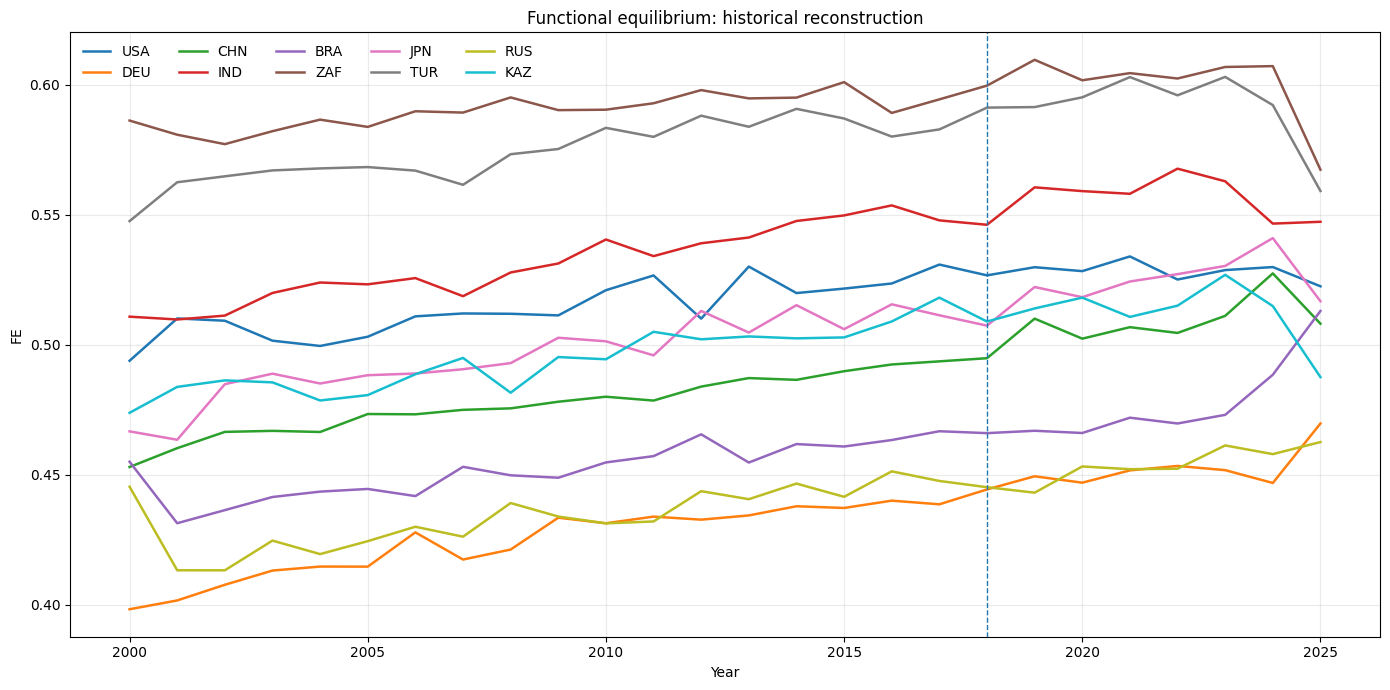

In [20]:
#@title 10.2. Исторические траектории AGIL
fig,ax=plt.subplots(figsize=(14,7))
for c in CFG.countries:
    g=wide[wide.country==c]
    ax.plot(g.year,g.FE,label=c,linewidth=1.8)
ax.axvline(CFG.train_end,linestyle="--",linewidth=1)
ax.set(title="Functional equilibrium: historical reconstruction",xlabel="Year",ylabel="FE")
ax.legend(ncol=5,frameon=False)
ax.grid(alpha=.25)
savefig("01_historical_FE")
PROGRESS.step("historical figure")

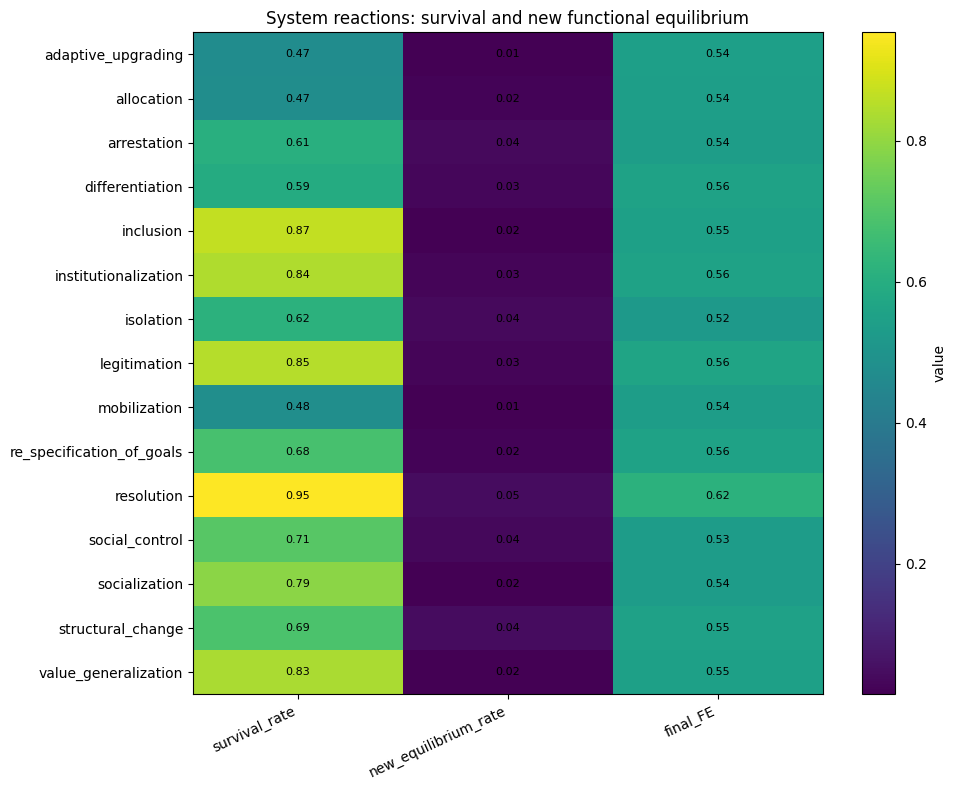

In [21]:
#@title 10.3. Карта эффективности реакций
mat=reaction_results.set_index("reaction")[["survival_rate","new_equilibrium_rate","final_FE"]]
fig,ax=plt.subplots(figsize=(10,8))
im=ax.imshow(mat.values,aspect="auto")
ax.set_xticks(range(mat.shape[1]),mat.columns,rotation=25,ha="right")
ax.set_yticks(range(mat.shape[0]),mat.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]): ax.text(j,i,f"{mat.iloc[i,j]:.2f}",ha="center",va="center",fontsize=8)
fig.colorbar(im,ax=ax,label="value")
ax.set_title("System reactions: survival and new functional equilibrium")
savefig("02_reaction_heatmap")
PROGRESS.step("reaction heatmap")

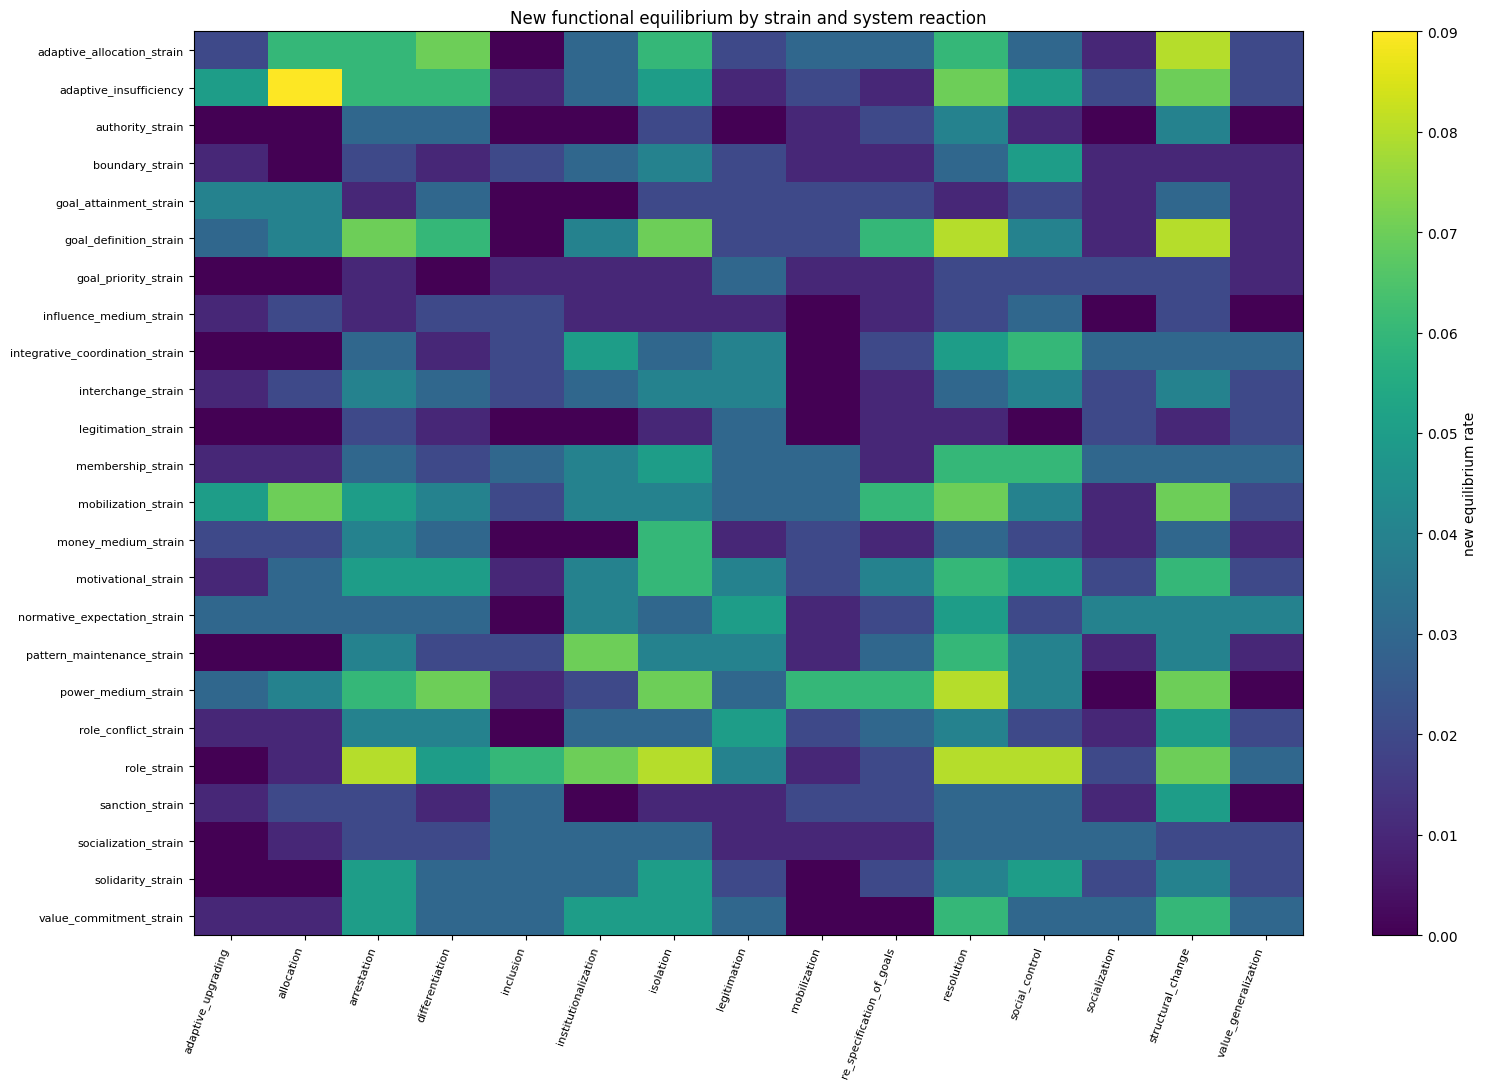

In [22]:
#@title 10.4. Strain × reaction: новое равновесие
pivot=(summary.groupby(["scenario","reaction"])["new_equilibrium"].mean().unstack())
fig,ax=plt.subplots(figsize=(16,11))
im=ax.imshow(pivot.values,aspect="auto")
ax.set_xticks(range(len(pivot.columns)),pivot.columns,rotation=70,ha="right",fontsize=8)
ax.set_yticks(range(len(pivot.index)),pivot.index,fontsize=8)
fig.colorbar(im,ax=ax,label="new equilibrium rate")
ax.set_title("New functional equilibrium by strain and system reaction")
savefig("03_strain_reaction_equilibrium")
PROGRESS.step("strain-reaction heatmap")

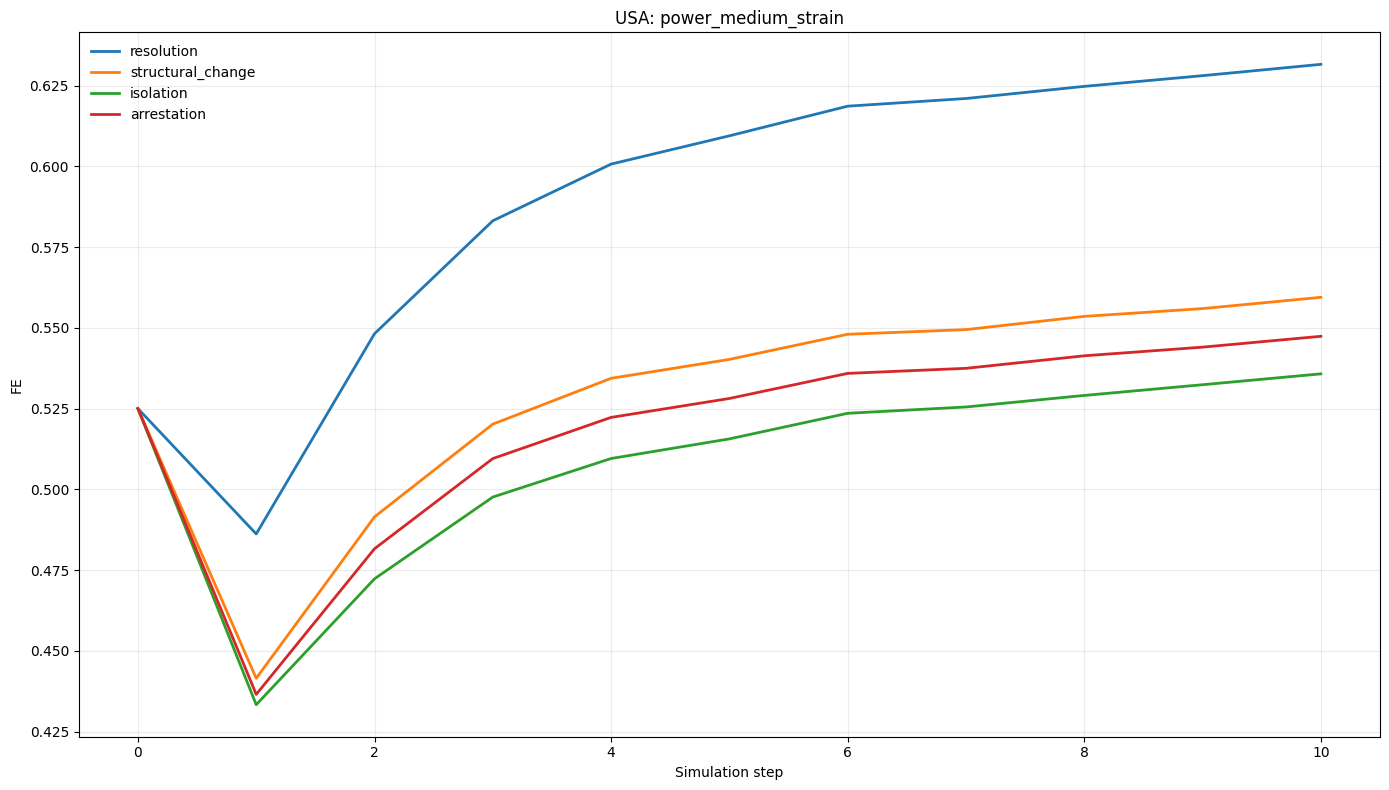

In [23]:
#@title 10.5. Пример траекторий AGIL после strain
example_country="USA"; example_scenario="power_medium_strain"
top_reactions=(reaction_results.sort_values("new_equilibrium_rate",ascending=False).reaction.head(4).tolist())
fig,ax=plt.subplots(figsize=(14,8))
for r in top_reactions:
    g=(trajectories[(trajectories.country==example_country)&(trajectories.scenario==example_scenario)&
                    (trajectories.reaction==r)].groupby("step")["FE"].mean())
    ax.plot(g.index,g.values,label=r,linewidth=2)
ax.set(title=f"{example_country}: {example_scenario}",xlabel="Simulation step",ylabel="FE")
ax.legend(frameon=False); ax.grid(alpha=.25)
savefig("04_example_trajectories")
PROGRESS.step("trajectory figure")

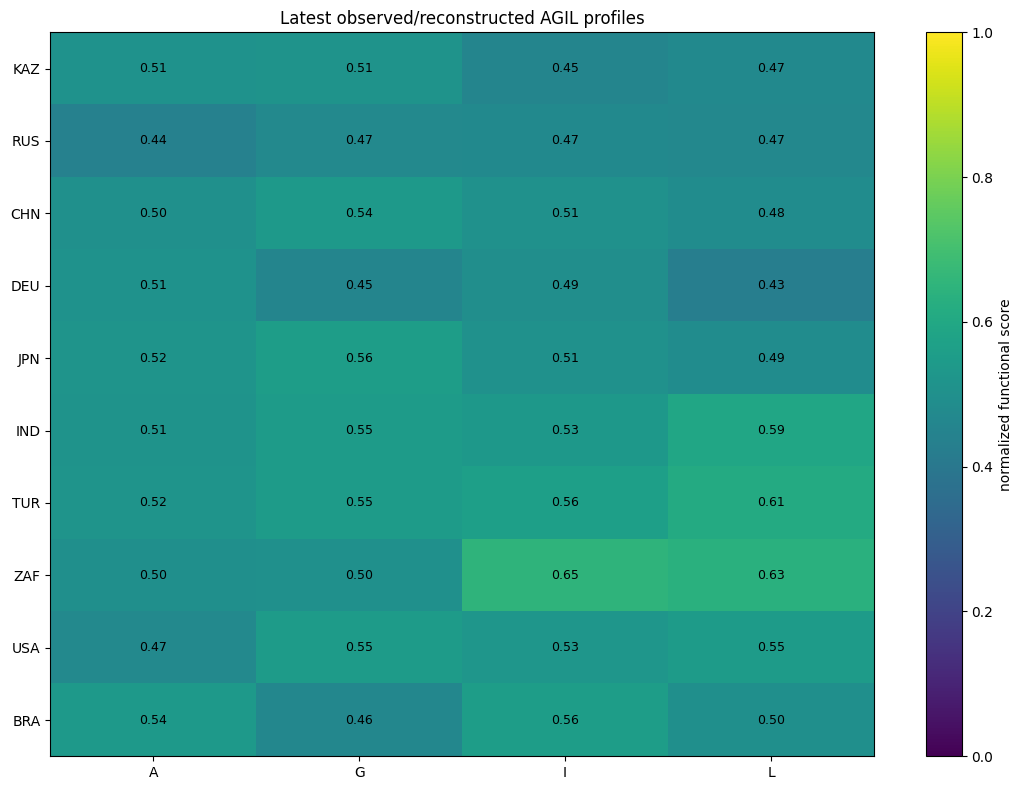

In [24]:
#@title 10.6. Страновые функциональные профили без нормативного ранжирования
latest=wide.sort_values("year").groupby("country").tail(1).set_index("country")[list(AGIL)]
fig,ax=plt.subplots(figsize=(11,8))
im=ax.imshow(latest.values,aspect="auto",vmin=0,vmax=1)
ax.set_xticks(range(4),AGIL)
ax.set_yticks(range(len(latest)),latest.index)
for i in range(latest.shape[0]):
    for j in range(4): ax.text(j,i,f"{latest.iloc[i,j]:.2f}",ha="center",va="center",fontsize=9)
fig.colorbar(im,ax=ax,label="normalized functional score")
ax.set_title("Latest observed/reconstructed AGIL profiles")
savefig("05_country_AGIL_profiles")
PROGRESS.step("country profile figure")

## 11. Экспорт

Создаются четыре книги Excel:

1. `01_Parsons_Data_Audit.xlsx`;
2. `02_Parsons_Historical_Model.xlsx`;
3. `03_Parsons_Simulation_Results.xlsx`;
4. `04_Parsons_Statistics.xlsx`.

Большие траектории дополнительно сохраняются в сжатые CSV, чтобы не превышать предел листа Excel. В Excel включаются агрегированные траектории и все итоговые таблицы.

In [25]:
#@title 11.1. Экспорт CSV и Excel
# CSV
for name,df in {
    "raw_panel":raw,"processed_panel":panel,"historical_agil":wide,"scenario_catalog":scenario_catalog,
    "reaction_catalog":reaction_catalog,"simulation_summary":summary,"reaction_results":reaction_results,
    "country_results":country_results,"scenario_results":scenario_results,"nonparametric":nonparametric,"pairwise":pairwise
}.items():
    df.to_csv(OUT/"tables_csv"/f"{name}.csv.gz",index=False,compression="gzip")

# Агрегированные траектории для Excel
traj_agg=(trajectories.groupby(["country","scenario","reaction","step"],as_index=False)
          .agg(**{f"{f}_mean":(f,"mean") for f in AGIL},
               FE_mean=("FE","mean"),FE_sd=("FE","std"),Strain_mean=("Strain","mean"),
               Bottleneck_mean=("Bottleneck","mean"),Institutionalization_mean=("Institutionalization","mean")))

with pd.ExcelWriter(OUT/"01_Parsons_Data_Audit.xlsx",engine="xlsxwriter") as xw:
    raw.to_excel(xw,"raw_long",index=False)
    coverage.to_excel(xw,"coverage",index=False)
    coverage_2025.to_excel(xw,"coverage_2025",index=False)
    indicator_meta.to_excel(xw,"indicator_dictionary",index=False)
with pd.ExcelWriter(OUT/"02_Parsons_Historical_Model.xlsx",engine="xlsxwriter") as xw:
    panel.to_excel(xw,"processed_panel",index=False)
    agil.to_excel(xw,"AGIL_long",index=False)
    wide.to_excel(xw,"AGIL_wide",index=False)
    validation_df.to_excel(xw,"validation",index=False)
    pd.DataFrame([THRESH]).to_excel(xw,"thresholds",index=False)
with pd.ExcelWriter(OUT/"03_Parsons_Simulation_Results.xlsx",engine="xlsxwriter") as xw:
    summary.to_excel(xw,"seed_results",index=False)
    traj_agg.to_excel(xw,"trajectories_aggregated",index=False)
    reaction_results.to_excel(xw,"reactions",index=False)
    country_results.to_excel(xw,"countries",index=False)
    scenario_results.to_excel(xw,"strain_classes",index=False)
    scenario_catalog.to_excel(xw,"scenario_catalog",index=False)
    reaction_catalog.to_excel(xw,"reaction_catalog",index=False)
with pd.ExcelWriter(OUT/"04_Parsons_Statistics.xlsx",engine="xlsxwriter") as xw:
    nonparametric.to_excel(xw,"friedman",index=False)
    pairwise.to_excel(xw,"wilcoxon_BH",index=False)

PROGRESS.step("Excel and CSV exported")

In [26]:
#@title 11.2. Манифест воспроизводимости, README и архив
manifest={
    "experiment":"Parsons Political System Computational Experiment",
    "version":"1.0",
    "config":asdict(CFG),
    "ontology_hash":ONTOLOGY_HASH,
    "data_mode_used":DATA_MODE_USED,
    "thresholds":THRESH,
    "countries":list(CFG.countries),
    "strain_classes":list(STRAIN_CLASSES),
    "reactions":list(REACTIONS),
    "indicator_map":{k:list(v) for k,v in INDICATORS.items()},
    "files":[],
}
for p in sorted(OUT.rglob("*")):
    if p.is_file():
        manifest["files"].append({"path":str(p.relative_to(OUT)),"bytes":p.stat().st_size,
                                  "sha256":hashlib.sha256(p.read_bytes()).hexdigest()})
(OUT/"manifest.json").write_text(json.dumps(manifest,ensure_ascii=False,indent=2),encoding="utf-8")

readme_lines = [
    "# Parsons Political System Experiment",
    "",
    f"Data mode: `{DATA_MODE_USED}`  ",
    f"Countries: {', '.join(CFG.countries)}  ",
    f"Years: {min(CFG.years)}–{max(CFG.years)}  ",
    f"Seeds: {CFG.n_seeds}  ",
    f"Strain classes: {len(STRAIN_CLASSES)}  ",
    f"System reactions: {len(REACTIONS)}",
    "",
    "The ontology is grounded in Talcott Parsons. Mathematical formulas and statistical procedures are computational operationalizations and are not attributed to Parsons.",
]
(OUT/"README.md").write_text("\n".join(readme_lines),encoding="utf-8")

archive=OUT.parent/"Parsons_Experiment_V1_outputs.zip"
with zipfile.ZipFile(archive,"w",zipfile.ZIP_DEFLATED) as z:
    for p in OUT.rglob("*"):
        if p.is_file(): z.write(p,p.relative_to(OUT.parent))
PROGRESS.step("manifest and archive")
PROGRESS.close()
print("Output directory:",OUT.resolve())
print("Archive:",archive.resolve())

Output directory: /content/parsons_experiment_outputs
Archive: /content/Parsons_Experiment_V1_outputs.zip


## 12. Интерпретационное ограничение

Результат `survival = 1` означает только отсутствие вычислительно определённого `breakdown` в заданном горизонте. `new_equilibrium = 1` означает восстановление взаимной совместимости функций и институционализации в рамках формальных критериев. Ни одна метрика не является моральной, демократической, геополитической или цивилизационной оценкой страны.